In [1]:
# Cell 1 - Setup SQLite Database
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Create database (saves as a file in your folder)
conn = sqlite3.connect("business_dashboard.db")
cursor = conn.cursor()

print("✅ Database connected successfully!")
print(f"SQLite version: {sqlite3.sqlite_version}")

✅ Database connected successfully!
SQLite version: 3.45.3


In [2]:
# Cell 2 - Create Tables & Load Data
# Think of this as building the filing cabinet before putting files in it

# --- Drop tables if they exist (clean slate) ---
cursor.executescript("""
    DROP TABLE IF EXISTS sales;
    DROP TABLE IF EXISTS customers;
    DROP TABLE IF EXISTS products;
""")

# --- Create Customers Table ---
cursor.executescript("""
    CREATE TABLE customers (
        customer_id     INTEGER PRIMARY KEY,
        customer_name   TEXT,
        region          TEXT,
        segment         TEXT
    );
""")

# --- Create Products Table ---
cursor.executescript("""
    CREATE TABLE products (
        product_id      INTEGER PRIMARY KEY,
        product_name    TEXT,
        category        TEXT,
        unit_price      REAL
    );
""")

# --- Create Sales Table ---
cursor.executescript("""
    CREATE TABLE sales (
        sale_id         INTEGER PRIMARY KEY,
        customer_id     INTEGER,
        product_id      INTEGER,
        sale_date       TEXT,
        quantity        INTEGER,
        discount        REAL,
        FOREIGN KEY (customer_id) REFERENCES customers(customer_id),
        FOREIGN KEY (product_id)  REFERENCES products(product_id)
    );
""")

print("✅ Tables created: customers | products | sales")

# --- Insert Customer Data ---
customers = [
    (1,  "Walmart",        "South",    "Retail"),
    (2,  "Target",         "Midwest",  "Retail"),
    (3,  "JPMorgan",       "East",     "Finance"),
    (4,  "Goldman Sachs",  "East",     "Finance"),
    (5,  "Dell",           "South",    "Technology"),
    (6,  "Apple",          "West",     "Technology"),
    (7,  "Amazon",         "West",     "Retail"),
    (8,  "Ford",           "Midwest",  "Manufacturing"),
    (9,  "Boeing",         "West",     "Manufacturing"),
    (10, "Pfizer",         "East",     "Healthcare"),
]

cursor.executemany(
    "INSERT INTO customers VALUES (?,?,?,?)", customers)

# --- Insert Product Data ---
products = [
    (1,  "Analytics Pro",      "Software",    4999.00),
    (2,  "Data Warehouse",     "Software",    8999.00),
    (3,  "Cloud Storage",      "Cloud",       1999.00),
    (4,  "Security Suite",     "Software",    3499.00),
    (5,  "Server Hardware",    "Hardware",    12999.00),
    (6,  "Laptop Bundle",      "Hardware",    2499.00),
    (7,  "Support Contract",   "Services",    999.00),
    (8,  "Consulting Hours",   "Services",    299.00),
    (9,  "AI Platform",        "Software",    15999.00),
    (10, "Network Equipment",  "Hardware",    5999.00),
]

cursor.executemany(
    "INSERT INTO products VALUES (?,?,?,?)", products)

# --- Insert Sales Data (120 transactions) ---
import random
from datetime import datetime, timedelta

random.seed(42)
sales = []
start_date = datetime(2024, 1, 1)

for sale_id in range(1, 121):
    customer_id = random.randint(1, 10)
    product_id  = random.randint(1, 10)
    sale_date   = (start_date + timedelta(days=random.randint(0, 364))).strftime("%Y-%m-%d")
    quantity    = random.randint(1, 10)
    discount    = random.choice([0.0, 0.05, 0.10, 0.15, 0.20])
    sales.append((sale_id, customer_id, product_id, sale_date, quantity, discount))

cursor.executemany(
    "INSERT INTO sales VALUES (?,?,?,?,?,?)", sales)

conn.commit()
print("✅ Data loaded: 10 customers | 10 products | 120 sales transactions")

✅ Tables created: customers | products | sales
✅ Data loaded: 10 customers | 10 products | 120 sales transactions


In [3]:
# Cell 3 - Your First SQL Queries
# We use pd.read_sql() to run SQL and return results as a pandas dataframe

# --- Query 1: Preview all tables ---
print("=== CUSTOMERS ===")
print(pd.read_sql("SELECT * FROM customers LIMIT 5", conn))

print("\n=== PRODUCTS ===")
print(pd.read_sql("SELECT * FROM products LIMIT 5", conn))

print("\n=== SALES (first 5 rows) ===")
print(pd.read_sql("SELECT * FROM sales LIMIT 5", conn))

=== CUSTOMERS ===
   customer_id  customer_name   region     segment
0            1        Walmart    South      Retail
1            2         Target  Midwest      Retail
2            3       JPMorgan     East     Finance
3            4  Goldman Sachs     East     Finance
4            5           Dell    South  Technology

=== PRODUCTS ===
   product_id     product_name  category  unit_price
0           1    Analytics Pro  Software      4999.0
1           2   Data Warehouse  Software      8999.0
2           3    Cloud Storage     Cloud      1999.0
3           4   Security Suite  Software      3499.0
4           5  Server Hardware  Hardware     12999.0

=== SALES (first 5 rows) ===
   sale_id  customer_id  product_id   sale_date  quantity  discount
0        1            2           1  2024-05-20         4      0.05
1        2            3           2  2024-12-12         9      0.00
2        3           10           7  2024-01-17         1      0.00
3        4            4           4  2

In [4]:
# Cell 4 - First Business Queries

# --- Q1: All unique regions ---
print("=== ALL REGIONS ===")
print(pd.read_sql("""
    SELECT DISTINCT region 
    FROM customers
    ORDER BY region
""", conn))

# --- Q2: Most expensive products ---
print("\n=== PRODUCTS BY PRICE (High to Low) ===")
print(pd.read_sql("""
    SELECT product_name, category, unit_price
    FROM products
    ORDER BY unit_price DESC
""", conn))

# --- Q3: What does one sales row mean? ---
print("\n=== ONE SALE FULLY EXPLAINED ===")
print(pd.read_sql("""
    SELECT 
        s.sale_id,
        c.customer_name,
        p.product_name,
        p.unit_price,
        s.quantity,
        s.discount,
        ROUND(p.unit_price * s.quantity * (1 - s.discount), 2) AS total_revenue
    FROM sales s
    JOIN customers c ON s.customer_id = c.customer_id
    JOIN products p  ON s.product_id  = p.product_id
    LIMIT 5
""", conn))

=== ALL REGIONS ===
    region
0     East
1  Midwest
2    South
3     West

=== PRODUCTS BY PRICE (High to Low) ===
        product_name  category  unit_price
0        AI Platform  Software     15999.0
1    Server Hardware  Hardware     12999.0
2     Data Warehouse  Software      8999.0
3  Network Equipment  Hardware      5999.0
4      Analytics Pro  Software      4999.0
5     Security Suite  Software      3499.0
6      Laptop Bundle  Hardware      2499.0
7      Cloud Storage     Cloud      1999.0
8   Support Contract  Services       999.0
9   Consulting Hours  Services       299.0

=== ONE SALE FULLY EXPLAINED ===
   sale_id  customer_name      product_name  unit_price  quantity  discount  \
0        1         Target     Analytics Pro      4999.0         4      0.05   
1        2       JPMorgan    Data Warehouse      8999.0         9      0.00   
2        3         Pfizer  Support Contract       999.0         1      0.00   
3        4  Goldman Sachs    Security Suite      3499.0      

In [5]:
# Cell 5 - Real Business Questions with GROUP BY

# --- Q1: Total Revenue by Customer (all 120 sales) ---
print("=== TOTAL REVENUE BY CUSTOMER ===")
print(pd.read_sql("""
    SELECT 
        c.customer_name,
        c.segment,
        c.region,
        COUNT(s.sale_id)                                            AS total_orders,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2)  AS total_revenue,
        ROUND(AVG(p.unit_price * s.quantity * (1-s.discount)), 2)  AS avg_order_value
    FROM sales s
    JOIN customers c ON s.customer_id = c.customer_id
    JOIN products p  ON s.product_id  = p.product_id
    GROUP BY c.customer_name, c.segment, c.region
    ORDER BY total_revenue DESC
""", conn))

=== TOTAL REVENUE BY CUSTOMER ===
   customer_name        segment   region  total_orders  total_revenue  \
0         Boeing  Manufacturing     West            19      521545.75   
1         Pfizer     Healthcare     East            12      424748.25   
2  Goldman Sachs        Finance     East            12      401844.60   
3       JPMorgan        Finance     East            14      339463.00   
4         Target         Retail  Midwest            13      307300.15   
5          Apple     Technology     West            11      291622.50   
6           Dell     Technology    South             9      290176.50   
7        Walmart         Retail    South            10      247132.50   
8           Ford  Manufacturing  Midwest            13      220185.75   
9         Amazon         Retail     West             7      198632.05   

   avg_order_value  
0         27449.78  
1         35395.69  
2         33487.05  
3         24247.36  
4         23638.47  
5         26511.14  
6         32241

In [6]:
# Cell 6 - Revenue Breakdowns

# --- Q1: Revenue by Category ---
print("=== REVENUE BY PRODUCT CATEGORY ===")
print(pd.read_sql("""
    SELECT 
        p.category,
        COUNT(s.sale_id)                                            AS total_orders,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2)  AS total_revenue,
        ROUND(AVG(s.discount) * 100, 1)                            AS avg_discount_pct
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    GROUP BY p.category
    ORDER BY total_revenue DESC
""", conn))

# --- Q2: Revenue by Region ---
print("\n=== REVENUE BY REGION ===")
print(pd.read_sql("""
    SELECT
        c.region,
        COUNT(s.sale_id)                                            AS total_orders,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2)  AS total_revenue,
        ROUND(AVG(p.unit_price * s.quantity * (1-s.discount)), 2)  AS avg_order_value
    FROM sales s
    JOIN customers c ON s.customer_id = c.customer_id
    JOIN products p  ON s.product_id  = p.product_id
    GROUP BY c.region
    ORDER BY total_revenue DESC
""", conn))

# --- Q3: Monthly Revenue Trend ---
print("\n=== MONTHLY REVENUE TREND ===")
print(pd.read_sql("""
    SELECT
        SUBSTR(s.sale_date, 1, 7)                                   AS month,
        COUNT(s.sale_id)                                            AS total_orders,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2)  AS total_revenue
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    GROUP BY month
    ORDER BY month
""", conn))

=== REVENUE BY PRODUCT CATEGORY ===
   category  total_orders  total_revenue  avg_discount_pct
0  Software            43     1755940.20               8.0
1  Hardware            37     1270082.80              10.4
2     Cloud            12      119840.05              10.8
3  Services            28       96788.00               8.2

=== REVENUE BY REGION ===
    region  total_orders  total_revenue  avg_order_value
0     East            38     1166055.85         30685.68
1     West            37     1011800.30         27345.95
2    South            19      537309.00         28279.42
3  Midwest            26      527485.90         20287.92

=== MONTHLY REVENUE TREND ===
      month  total_orders  total_revenue
0   2024-01             7      155932.95
1   2024-02            13      446254.05
2   2024-03             5       32520.75
3   2024-04             9      242881.90
4   2024-05            17      578027.15
5   2024-06            13      297433.20
6   2024-07             9       98371.4

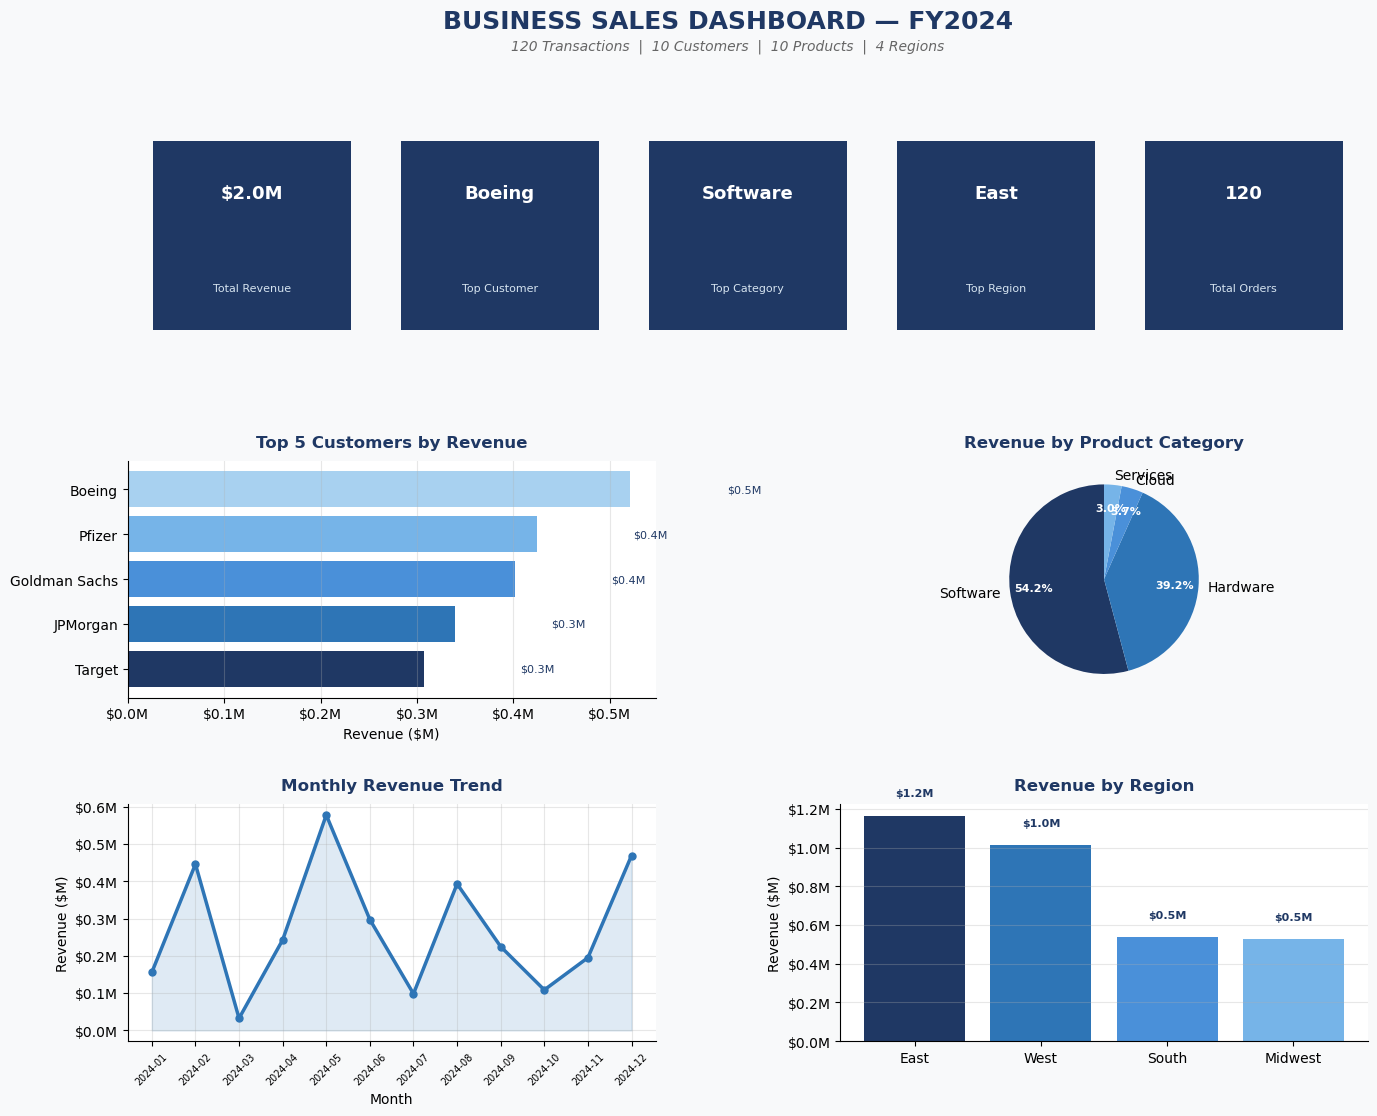

✅ Dashboard saved as business_dashboard.png


In [7]:
# Cell 7 - Business Dashboard

# --- Pull data for charts ---
df_customer = pd.read_sql("""
    SELECT c.customer_name,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2) AS total_revenue
    FROM sales s
    JOIN customers c ON s.customer_id = c.customer_id
    JOIN products p  ON s.product_id  = p.product_id
    GROUP BY c.customer_name
    ORDER BY total_revenue DESC
    LIMIT 5
""", conn)

df_category = pd.read_sql("""
    SELECT p.category,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2) AS total_revenue
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    GROUP BY p.category
    ORDER BY total_revenue DESC
""", conn)

df_region = pd.read_sql("""
    SELECT c.region,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2) AS total_revenue
    FROM sales s
    JOIN customers c ON s.customer_id = c.customer_id
    JOIN products p  ON s.product_id  = p.product_id
    GROUP BY c.region
    ORDER BY total_revenue DESC
""", conn)

df_monthly = pd.read_sql("""
    SELECT SUBSTR(s.sale_date, 1, 7) AS month,
        ROUND(SUM(p.unit_price * s.quantity * (1-s.discount)), 2) AS total_revenue
    FROM sales s
    JOIN products p ON s.product_id = p.product_id
    GROUP BY month
    ORDER BY month
""", conn)

# --- Build Dashboard ---
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#F8F9FA")

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

DARK_BLUE  = "#1F3864"
MID_BLUE   = "#2E75B6"
LIGHT_BLUE = "#D6E4F0"
COLORS     = ["#1F3864", "#2E75B6", "#4A90D9", "#76B4E8", "#A8D1F0"]

# --- Title ---
fig.text(0.5, 0.97, "BUSINESS SALES DASHBOARD — FY2024",
         ha="center", va="top",
         fontsize=18, fontweight="bold", color=DARK_BLUE)
fig.text(0.5, 0.945, "120 Transactions  |  10 Customers  |  10 Products  |  4 Regions",
         ha="center", va="top",
         fontsize=10, color="#666666", style="italic")

# --- KPI Row ---
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor("#F8F9FA")
ax_kpi.axis("off")

total_rev  = df_customer["total_revenue"].sum()
top_cust   = df_customer.iloc[0]["customer_name"]
top_cat    = df_category.iloc[0]["category"]
top_region = df_region.iloc[0]["region"]

kpis = [
    ("Total Revenue",    f"${total_rev/1e6:.1f}M"),
    ("Top Customer",     top_cust),
    ("Top Category",     top_cat),
    ("Top Region",       top_region),
    ("Total Orders",     "120"),
]

for i, (label, value) in enumerate(kpis):
    x = 0.1 + i * 0.2
    ax_kpi.add_patch(plt.Rectangle((x-0.08, 0.1), 0.16, 0.8,
                     transform=ax_kpi.transAxes,
                     facecolor=DARK_BLUE, edgecolor="none",
                     clip_on=False, zorder=2))
    ax_kpi.text(x, 0.68, value, transform=ax_kpi.transAxes,
                ha="center", va="center",
                fontsize=13, fontweight="bold", color="white", zorder=3)
    ax_kpi.text(x, 0.28, label, transform=ax_kpi.transAxes,
                ha="center", va="center",
                fontsize=8, color=LIGHT_BLUE, zorder=3)

# --- Chart 1: Top 5 Customers ---
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor("white")
bars = ax1.barh(df_customer["customer_name"][::-1],
                df_customer["total_revenue"][::-1] / 1e6,
                color=COLORS)
ax1.set_title("Top 5 Customers by Revenue", fontweight="bold",
              color=DARK_BLUE, pad=10)
ax1.set_xlabel("Revenue ($M)")
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}M"))
for bar, val in zip(bars, df_customer["total_revenue"][::-1]):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f"${val/1e6:.1f}M", va="center", fontsize=8, color=DARK_BLUE)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="x", alpha=0.3)

# --- Chart 2: Revenue by Category ---
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor("white")
wedges, texts, autotexts = ax2.pie(
    df_category["total_revenue"],
    labels=df_category["category"],
    autopct="%1.1f%%",
    colors=COLORS,
    startangle=90,
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontsize(8)
    text.set_color("white")
    text.set_fontweight("bold")
ax2.set_title("Revenue by Product Category", fontweight="bold",
              color=DARK_BLUE, pad=10)

# --- Chart 3: Monthly Revenue Trend ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.set_facecolor("white")
ax3.plot(df_monthly["month"], df_monthly["total_revenue"] / 1e6,
         color=MID_BLUE, linewidth=2.5, marker="o", markersize=5)
ax3.fill_between(df_monthly["month"], df_monthly["total_revenue"] / 1e6,
                 alpha=0.15, color=MID_BLUE)
ax3.set_title("Monthly Revenue Trend", fontweight="bold",
              color=DARK_BLUE, pad=10)
ax3.set_xlabel("Month")
ax3.set_ylabel("Revenue ($M)")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}M"))
ax3.tick_params(axis="x", rotation=45, labelsize=7)
ax3.spines[["top", "right"]].set_visible(False)
ax3.grid(alpha=0.3)

# --- Chart 4: Revenue by Region ---
ax4 = fig.add_subplot(gs[2, 1])
ax4.set_facecolor("white")
bars2 = ax4.bar(df_region["region"], df_region["total_revenue"] / 1e6,
                color=COLORS[:len(df_region)])
ax4.set_title("Revenue by Region", fontweight="bold",
              color=DARK_BLUE, pad=10)
ax4.set_ylabel("Revenue ($M)")
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}M"))
for bar, val in zip(bars2, df_region["total_revenue"]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"${val/1e6:.1f}M", ha="center", fontsize=8,
             color=DARK_BLUE, fontweight="bold")
ax4.spines[["top", "right"]].set_visible(False)
ax4.grid(axis="y", alpha=0.3)

plt.savefig("business_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor="#F8F9FA")
plt.show()
print("✅ Dashboard saved as business_dashboard.png")